# Airbnb NYC Dataset – Exploratory Data Analysis (EDA)

## Project Objective

The objective of this exploratory data analysis is to understand the characteristics of Airbnb listings in New York City by analyzing pricing, room types, neighbourhoods, host activity, availability, and customer reviews. The analysis aims to identify meaningful patterns, trends, and relationships that can provide business insights and support data-driven decision-making.

## Table of Contents

1. Univariate Analysis
2. Bivariate Analysis
3. Multivariate Analysis
4. Final Conclusion

In [53]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

In [54]:
df = pd.read_csv('/content/airbnb_cleaned.csv')

In [55]:
df.head()

,id,name,host_id,host_name,neighbourhood_group,neighbourhood,latitude,longitude,room_type,price,minimum_nights,number_of_reviews,last_review,reviews_per_month,calculated_host_listings_count,availability_365
0,2539,Clean & quiet apt home by the park,2787,John,Brooklyn,Kensington,40.64749,-73.97237,Private room,149,1,9,2018-10-19,0.21,6,365
1,2595,Skylit Midtown Castle,2845,Jennifer,Manhattan,Midtown,40.75362,-73.98377,Entire home/apt,225,1,45,2019-05-21,0.38,2,355
2,3647,THE VILLAGE OF HARLEM....NEW YORK !,4632,Elisabeth,Manhattan,Harlem,40.80902,-73.94190,Private room,150,3,0,NaN,NaN,1,365
3,3831,Cozy Entire Floor of Brownstone,4869,LisaRoxanne,Brooklyn,Clinton Hill,40.68514,-73.95976,Entire home/apt,89,1,270,2019-07-05,4.64,1,194
4,5022,Entire Apt: Spacious Studio/Loft by central park,7192,Laura,Manhattan,East Harlem,40.79851,-73.94399,Entire home/apt,80,10,9,2018-11-19,0.10,1,0


In [56]:
df.shape

(48884, 16)

In [57]:
df['neighbourhood_group'] = df['neighbourhood_group'].astype('category')
df['neighbourhood'] = df['neighbourhood'].astype('category')
df['room_type'] = df['room_type'].astype('category')
df['last_review'] = pd.to_datetime(df['last_review'])

In [58]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 48884 entries, 0 to 48883
Data columns (total 16 columns):
 #   Column                          Non-Null Count  Dtype         
---  ------                          --------------  -----         
 0   id                              48884 non-null  int64         
 1   name                            48884 non-null  object        
 2   host_id                         48884 non-null  int64         
 3   host_name                       48884 non-null  object        
 4   neighbourhood_group             48884 non-null  category      
 5   neighbourhood                   48884 non-null  category      
 6   latitude                        48884 non-null  float64       
 7   longitude                       48884 non-null  float64       
 8   room_type                       48884 non-null  category      
 9   price                           48884 non-null  int64         
 10  minimum_nights                  48884 non-null  int64         
 11  nu

# 1. Univariate Analysis

## 1.1 Price Distribution
**Business Question**

What is the distribution of Airbnb listing prices in New York City?

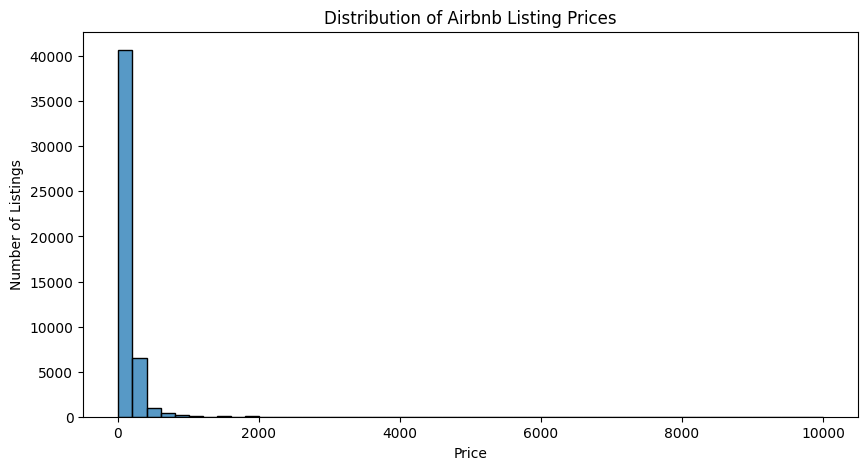

In [59]:
plt.figure(figsize=(10,5))

sns.histplot(data=df, x='price', bins=50)

plt.title('Distribution of Airbnb Listing Prices')
plt.xlabel('Price')
plt.ylabel('Number of Listings')

plt.show()

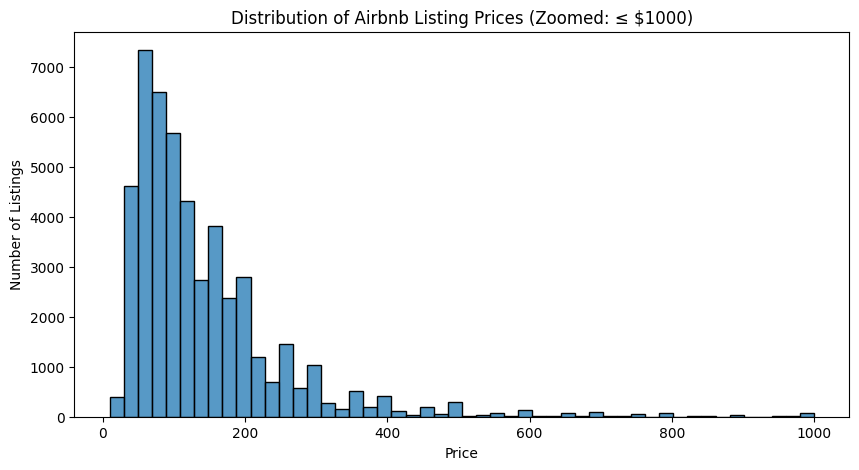

In [60]:
plt.figure(figsize=(10,5))

sns.histplot(data=df[df['price'] <= 1000], x='price', bins=50)

plt.title('Distribution of Airbnb Listing Prices (Zoomed: ≤ $1000)')
plt.xlabel('Price')
plt.ylabel('Number of Listings')

plt.show()

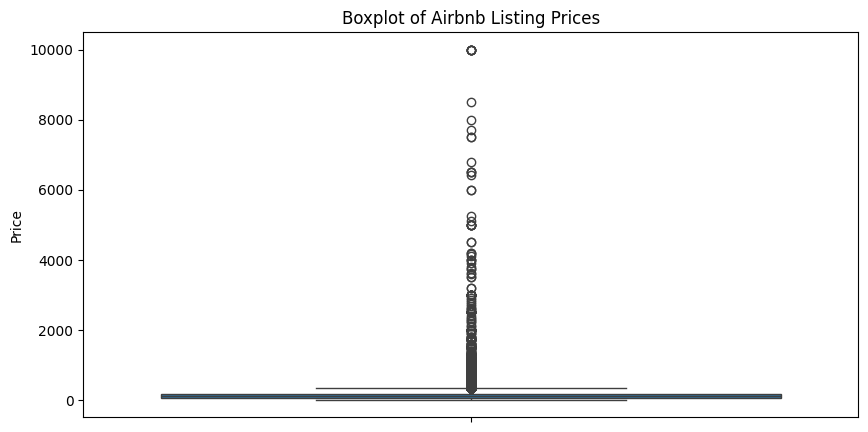

In [61]:
plt.figure(figsize=(10,5))

sns.boxplot(data=df, y='price')

plt.title('Boxplot of Airbnb Listing Prices')
plt.ylabel('Price')
plt.show()

**Interpretation**

The distribution of Airbnb listing prices in New York City is highly right-skewed, indicating that most listings are concentrated in the lower price range. The zoomed histogram shows that the majority of properties are priced below $200 per night, with the frequency of listings decreasing as prices increase. The boxplot further confirms the presence of numerous upper outliers, representing a relatively small number of premium and luxury listings with significantly higher prices. These outliers are considered genuine observations and were retained during the data cleaning process.

**Business Insight**

The Airbnb market in New York City is primarily driven by budget and mid-range accommodations, making the platform accessible to a broad range of travelers. While luxury listings are available, they account for only a small proportion of the market. This suggests that hosts generally price their properties competitively to attract a larger customer base, with only a limited number targeting the premium segment.

## 1.2 Room Type Distribution
**Business Question**

What is the distribution of room types among Airbnb listings in New York City?

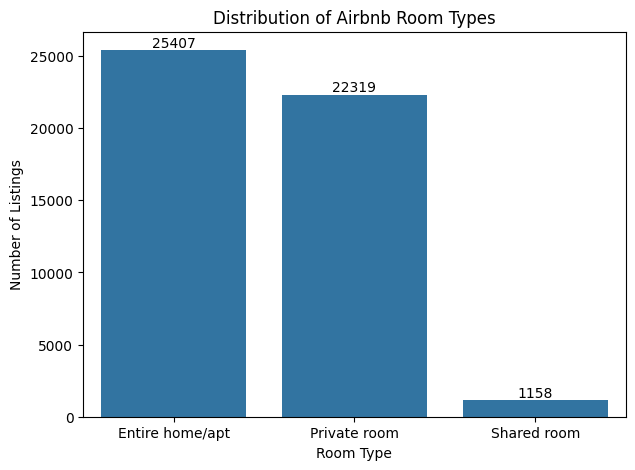

In [62]:
plt.figure(figsize=(7,5))

ax = sns.countplot(data=df, x='room_type')

plt.title('Distribution of Airbnb Room Types')
plt.xlabel('Room Type')
plt.ylabel('Number of Listings')

for container in ax.containers:
    ax.bar_label(container, fmt='%.0f')

plt.show()

**Interpretation**

The count plot shows that Entire home/apartment is the most common room type, accounting for the largest share of Airbnb listings in New York City. Private rooms are the second most frequently listed accommodation type and also represent a significant portion of the market. In contrast, Shared rooms are comparatively rare, making up only a small fraction of the total listings.

**Business Insight**

The Airbnb market in New York City is dominated by Entire home/apartment and Private room listings, indicating that guests generally prefer greater privacy and personal space. The relatively low number of Shared room listings suggests limited demand or lower host preference for this accommodation type. Hosts looking to attract a broader customer base may find greater opportunities by offering entire homes or private rooms.

## 1.3 Neighbourhood Group Distribution
**Business Question**

Which neighbourhood groups have the highest number of Airbnb listings in New York City?

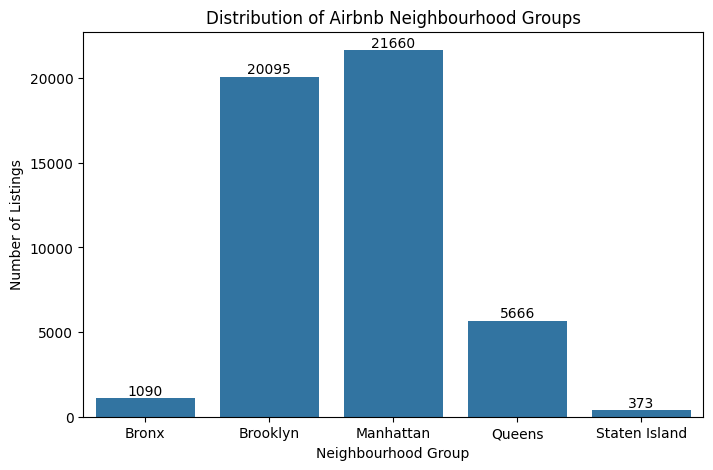

In [63]:
plt.figure(figsize=(8,5))

ax = sns.countplot(data=df, x='neighbourhood_group')

plt.title('Distribution of Airbnb Neighbourhood Groups')
plt.xlabel('Neighbourhood Group')
plt.ylabel('Number of Listings')

for container in ax.containers:
    ax.bar_label(container, fmt='%.0f')

plt.show()

**Interpretation**

The count plot shows that Manhattan has the highest number of Airbnb listings, closely followed by Brooklyn. Queens has a considerably smaller number of listings, while Bronx and Staten Island contribute only a small share of the total listings. This indicates that Airbnb listings are heavily concentrated in Manhattan and Brooklyn.

**Business Insight**

The concentration of Airbnb listings in Manhattan and Brooklyn suggests that these boroughs are the primary Airbnb markets in New York City, likely due to their popularity among tourists, business travelers, and residents. In contrast, the relatively low number of listings in the Bronx and Staten Island may indicate lower tourism demand, fewer hosts, or reduced market penetration in these areas.

## 1.4 Minimum Nights Distribution
**Business Question**

What is the distribution of minimum night requirements among Airbnb listings in New York City?

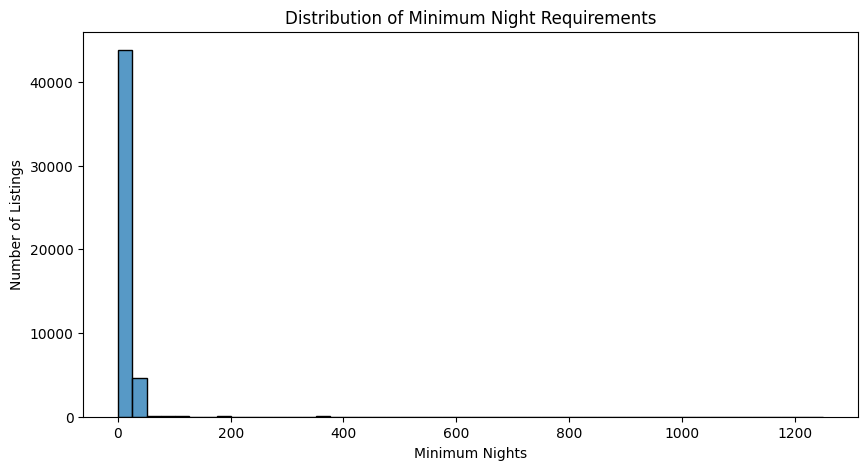

In [64]:
plt.figure(figsize=(10,5))

sns.histplot(data=df, x='minimum_nights', bins=50)

plt.title('Distribution of Minimum Night Requirements')
plt.xlabel('Minimum Nights')
plt.ylabel('Number of Listings')

plt.show()

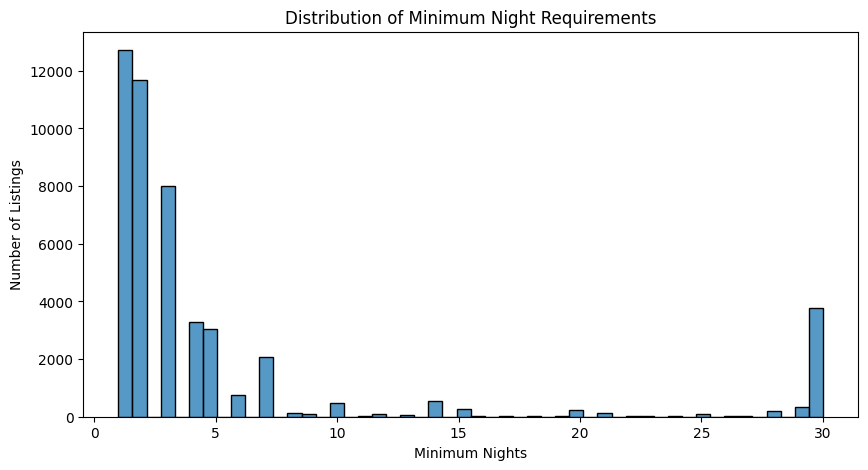

In [65]:
plt.figure(figsize=(10,5))

sns.histplot(data=df[df['minimum_nights']<=30], x='minimum_nights', bins=50)

plt.title('Distribution of Minimum Night Requirements')
plt.xlabel('Minimum Nights')
plt.ylabel('Number of Listings')

plt.show()

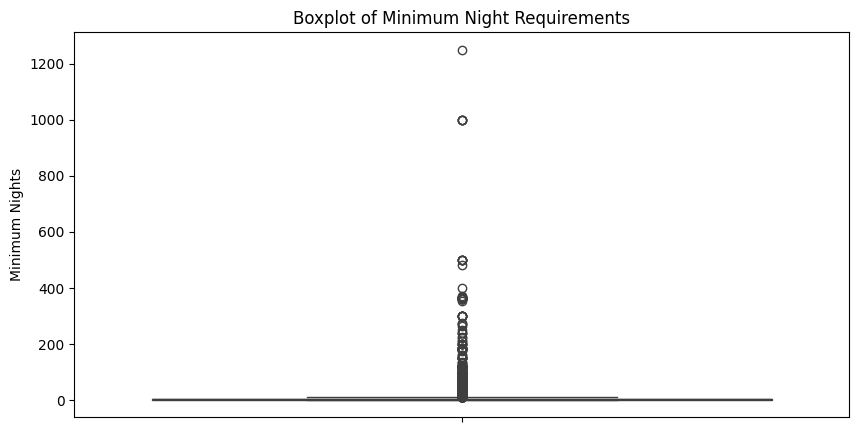

In [66]:
plt.figure(figsize=(10,5))

sns.boxplot(data=df, y='minimum_nights')

plt.title('Boxplot of Minimum Night Requirements')
plt.ylabel('Minimum Nights')

plt.show()

**Interpretation**

The distribution of minimum night requirements is highly right-skewed, with the majority of Airbnb listings requiring only 1 to 3 nights as the minimum stay. The zoomed histogram shows that the frequency of listings decreases as the minimum stay requirement increases, although there is a noticeable spike at 30 nights, indicating a substantial number of long-term rental listings. The boxplot confirms the presence of several upper outliers with exceptionally high minimum stay requirements. These values were investigated during the data cleaning phase and retained, as they represent legitimate long-term rental policies rather than data quality issues.

**Business Insight**

The findings indicate that most Airbnb hosts in New York City cater to short-term travelers by offering flexible minimum stay requirements. At the same time, the significant number of listings with a 30-night minimum stay suggests a well-established market for extended stays, such as business travel, temporary relocation, and student accommodation. This demonstrates that the platform serves both short-term and long-term accommodation needs.

## 1.5 Availability Distribution
**Business Question**

How available are Airbnb listings throughout the year?

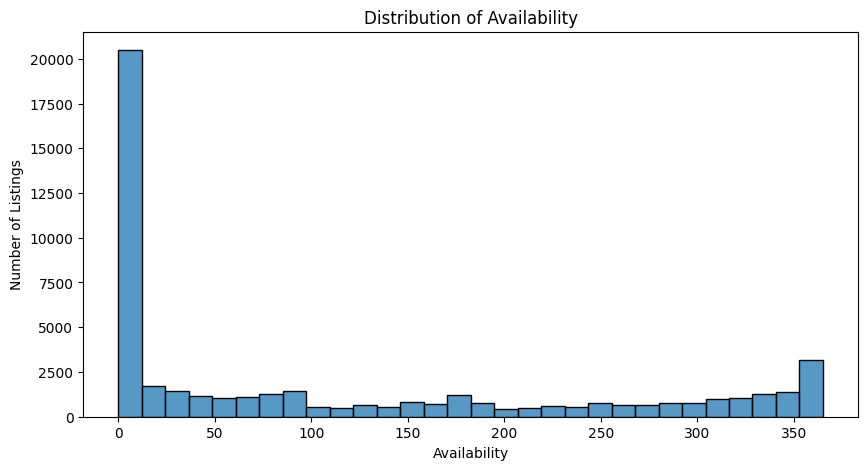

In [67]:
plt.figure(figsize=(10,5))

sns.histplot(data=df, x='availability_365')

plt.title('Distribution of Availability')
plt.xlabel('Availability')
plt.ylabel('Number of Listings')

plt.show()

**Interpretation**

The distribution of availability_365 is non-normal and exhibits two distinct concentrations. A large number of listings have very low annual availability, indicating that they are unavailable for most of the year, while another substantial group remains available for nearly all 365 days. Comparatively fewer listings fall within the middle range of annual availability. This suggests that Airbnb listings vary considerably in how frequently they are offered to guests.

**Business Insight**

The two peaks in the distribution suggest the presence of different hosting strategies. Listings with very low availability may represent highly booked properties or hosts who make their properties available only during specific periods. In contrast, listings with availability close to 365 days are likely managed by hosts who keep their properties consistently available throughout the year. This indicates that the Airbnb marketplace serves both occasional hosts and full-time rental operators.

## 1.6 Number of Reviews Distribution
**Business Question**

How are Airbnb listings distributed based on the number of customer reviews?

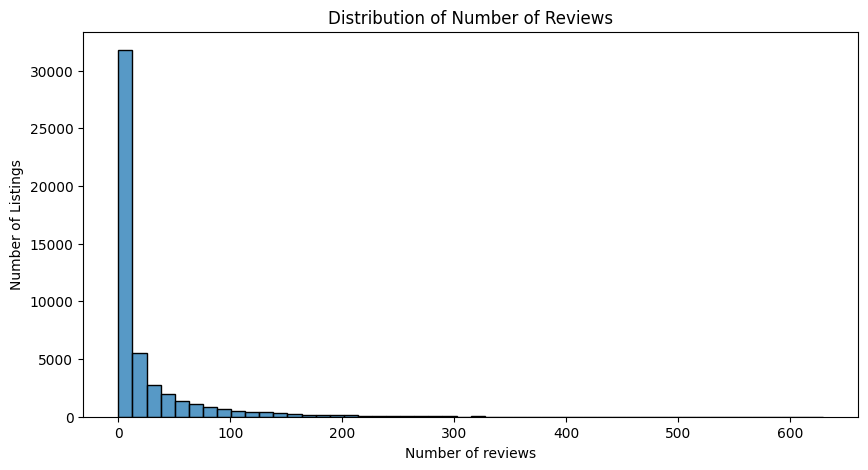

In [68]:
plt.figure(figsize=(10,5))

sns.histplot(data=df, x='number_of_reviews', bins=50)

plt.title('Distribution of Number of Reviews')
plt.xlabel('Number of reviews')
plt.ylabel('Number of Listings')

plt.show()

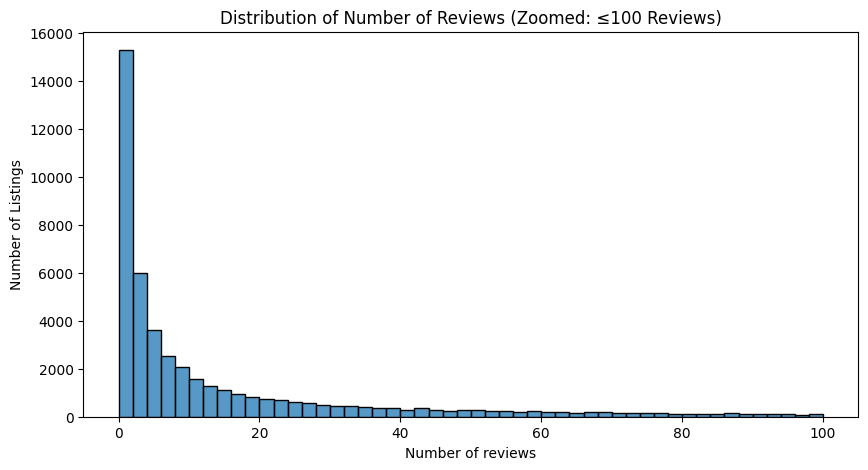

In [69]:
plt.figure(figsize=(10,5))

sns.histplot(data=df[df['number_of_reviews']<=100], x='number_of_reviews', bins=50)

plt.title('Distribution of Number of Reviews (Zoomed: ≤100 Reviews)')
plt.xlabel('Number of reviews')
plt.ylabel('Number of Listings')

plt.show()

**Interpretation**

The distribution of the number of reviews is highly right-skewed, with most Airbnb listings receiving relatively few reviews. The zoomed histogram shows that a large proportion of listings have fewer than 20 reviews, and the frequency gradually decreases as the number of reviews increases. Only a small number of listings accumulate several hundred reviews, representing highly popular or long-established properties. The distribution also contains legitimate upper outliers, which were retained during the data cleaning process.

**Business Insight**

Most Airbnb listings in New York City receive a limited number of customer reviews, suggesting that many properties are either relatively new, booked less frequently, or receive fewer guest interactions. In contrast, a small number of listings have accumulated a large number of reviews, indicating consistent bookings, high popularity, or long-term activity on the platform.

# 2. Bivariate Analysis

## 2.1 Price vs Room Type
**Business Question**

How does the price of Airbnb listings vary across different room types?

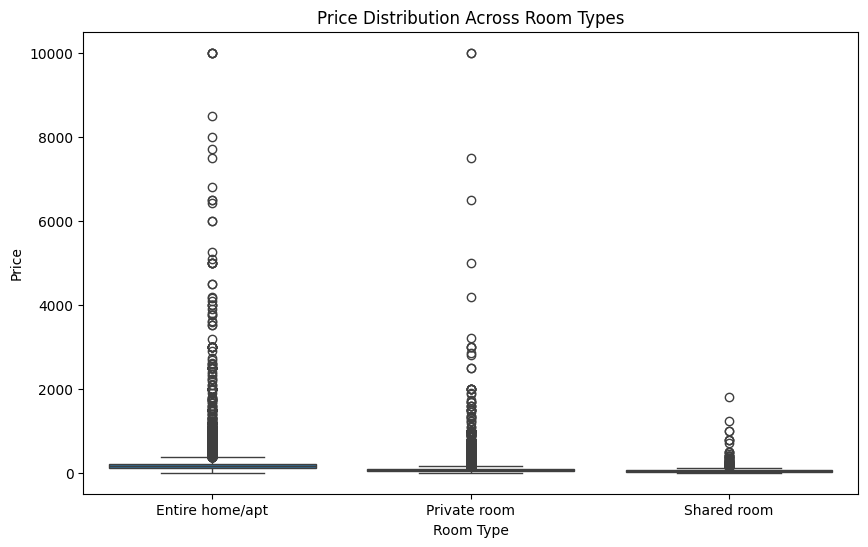

In [70]:
plt.figure(figsize=(10,6))

sns.boxplot(data=df, x='room_type', y='price')

plt.title('Price Distribution Across Room Types')
plt.xlabel('Room Type')
plt.ylabel('Price')

plt.show()

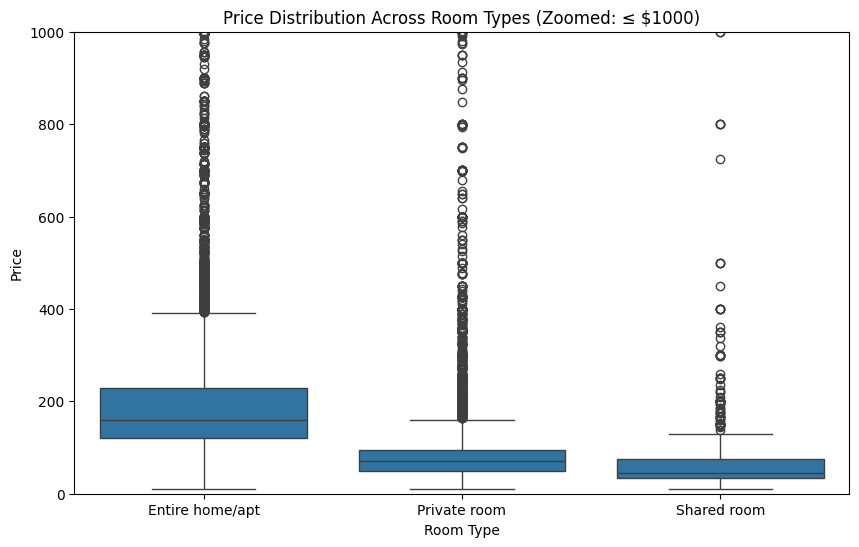

In [71]:
plt.figure(figsize=(10,6))

sns.boxplot(data=df, x='room_type', y='price')

plt.title('Price Distribution Across Room Types (Zoomed: ≤ $1000)')
plt.xlabel('Room Type')
plt.ylabel('Price')

plt.ylim(0, 1000)

plt.show()

**Interpretation**

The boxplot shows a clear difference in pricing across room types. Entire home/apartment listings have the highest median price and the widest price distribution, indicating that they are generally more expensive and exhibit greater price variability. Private rooms have a considerably lower median price and a narrower price range, while Shared rooms are the most affordable accommodation type with the lowest median price. Although all three room types contain upper outliers, the highest-priced listings are predominantly found among Entire home/apartment and Private room accommodations.

**Business Insight**

Room type is a major factor influencing Airbnb pricing in New York City. Guests seeking greater privacy and exclusive use of a property typically pay higher prices for Entire home/apartment listings. In contrast, Private rooms and Shared rooms provide more budget-friendly alternatives, making them attractive options for cost-conscious travelers. Hosts can use room type as a key pricing strategy when positioning their listings in the market.

## 2.2 Price vs Neighbourhood Group
**Business Question**

How does the price of Airbnb listings vary across different neighbourhood groups in New York City?

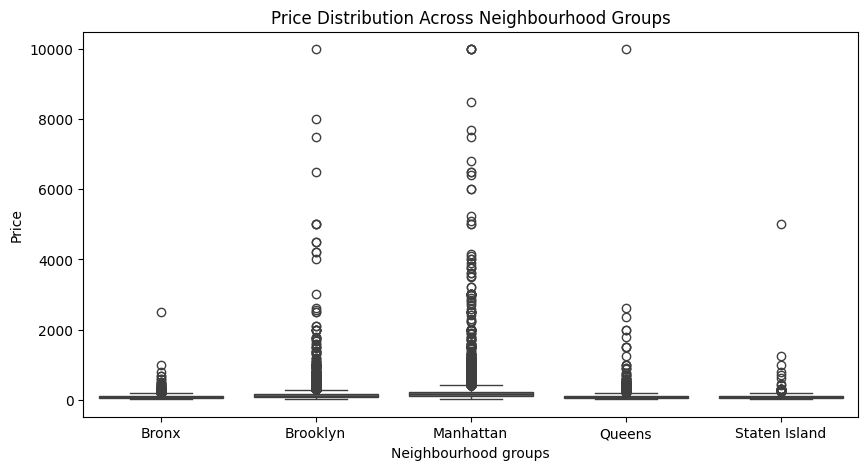

In [72]:
plt.figure(figsize=(10,5))

sns.boxplot(data=df, x='neighbourhood_group', y='price')

plt.title('Price Distribution Across Neighbourhood Groups')
plt.xlabel('Neighbourhood groups')
plt.ylabel('Price')

plt.show()


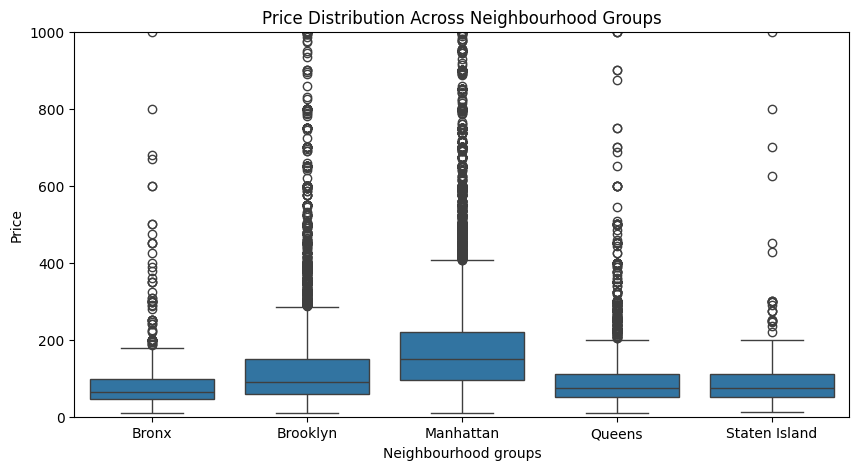

In [73]:
plt.figure(figsize=(10,5))

sns.boxplot(data=df, x='neighbourhood_group', y='price')

plt.title('Price Distribution Across Neighbourhood Groups')
plt.xlabel('Neighbourhood groups')
plt.ylabel('Price')

plt.ylim(0,1000)

plt.show()

**Interpretation**

The boxplot shows clear differences in Airbnb listing prices across New York City's neighbourhood groups. Manhattan has the highest median listing price and the widest price distribution, indicating that accommodations in this borough are generally more expensive and exhibit greater price variability. Brooklyn has the second-highest median price, while Queens, Bronx, and Staten Island have comparatively lower median prices. Although all neighbourhood groups contain high-priced outliers, the majority of premium-priced listings are concentrated in Manhattan and Brooklyn.

**Business Insight**

The results indicate that location is a key driver of Airbnb pricing in New York City. Listings in Manhattan and Brooklyn command higher prices due to factors such as high tourist demand, business activity, accessibility, and proximity to major attractions. In contrast, Queens, Bronx, and Staten Island generally offer more affordable accommodation options, making them attractive choices for budget-conscious travelers.

## 2.3 Price vs Number of Reviews
**Business Question**

Is there a relationship between the price of an Airbnb listing and the number of customer reviews it receives?

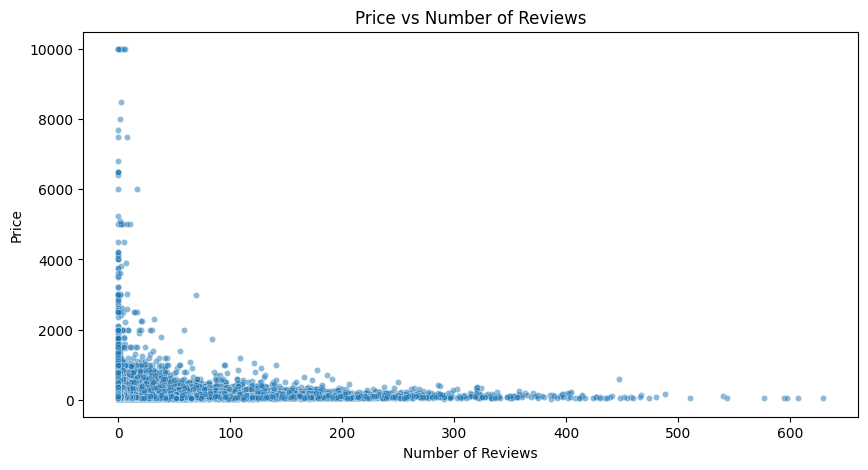

In [74]:
plt.figure(figsize=(10,5))

sns.scatterplot(data=df, x='number_of_reviews', y='price', alpha=0.5, s=20)

plt.title('Price vs Number of Reviews')
plt.xlabel('Number of Reviews')
plt.ylabel('Price')

plt.show()

**Interpretation**

The scatter plot shows no strong linear relationship between the price of an Airbnb listing and the number of customer reviews. Most listings are concentrated in the lower to moderate price range and have relatively few reviews. Listings with a large number of reviews are generally priced at affordable to moderate levels, while extremely expensive listings tend to receive fewer reviews. Although several high-priced outliers are present, they do not exhibit any clear pattern with respect to the number of reviews.

**Business Insight**

The findings suggest that pricing alone does not determine the popularity of an Airbnb listing. Moderately priced listings appear to attract more bookings and, consequently, accumulate a higher number of customer reviews. In contrast, premium-priced properties cater to a smaller customer segment and generally receive fewer reviews. This indicates that affordability may contribute to higher booking frequency and increased customer engagement.

## 2.4 Price vs Minimum Nights
**Business Question**

How does the price of Airbnb listings vary with the minimum night requirement?

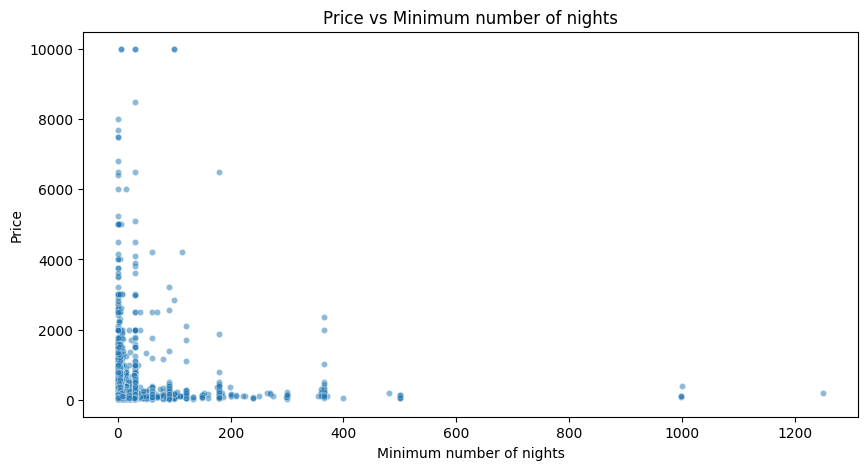

In [75]:
plt.figure(figsize=(10,5))

sns.scatterplot(data=df, x='minimum_nights', y='price', alpha=0.5, s=20)

plt.title('Price vs Minimum number of nights')
plt.xlabel('Minimum number of nights')
plt.ylabel('Price')

plt.show()

**Interpretation**

The scatter plot shows no strong linear relationship between the price of an Airbnb listing and its minimum night requirement. Most listings are concentrated at lower minimum night requirements, particularly between 1 and 30 nights, with prices varying widely within this range. Listings with exceptionally high minimum night requirements are relatively rare and are generally associated with moderate price levels. Several high-priced outliers exist, but they are primarily concentrated among listings with lower minimum stay requirements.

**Business Insight**

The findings suggest that minimum stay requirements alone do not have a significant influence on listing prices. While most Airbnb listings require only a few nights as the minimum stay, hosts adopt a wide range of pricing strategies within this segment. Other factors, such as room type, location, property amenities, and demand, are likely to have a greater impact on pricing than the minimum night requirement itself.

## 2.5 Price vs Availability
**Business Question**

Is there a relationship between the price of an Airbnb listing and its annual availability?

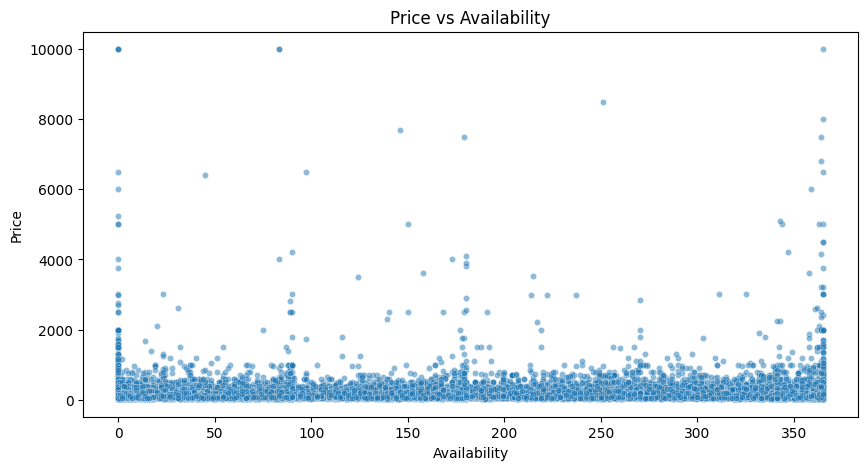

In [76]:
plt.figure(figsize=(10,5))

sns.scatterplot(data=df, x='availability_365', y='price', alpha=0.5, s=20)

plt.title('Price vs Availability')
plt.xlabel('Availability')
plt.ylabel('Price')

plt.show()

**Interpretation**

The scatter plot indicates no strong linear relationship between the price of Airbnb listings and their annual availability. Listings are spread across the entire availability range, with the majority of prices remaining in the lower to moderate range regardless of availability. A few high-priced outliers are present at both low and high availability levels, but they do not form any consistent trend.

**Business Insight**

The results suggest that annual availability alone is not a strong determinant of Airbnb listing prices. Listings with both low and high availability exhibit a wide range of prices, indicating that other factors such as location, room type, property size, and amenities are likely to play a more significant role in pricing decisions than availability.

## 2.6 Number of Reviews vs Room Type
**Business Question**

How does the number of customer reviews vary across different room types?

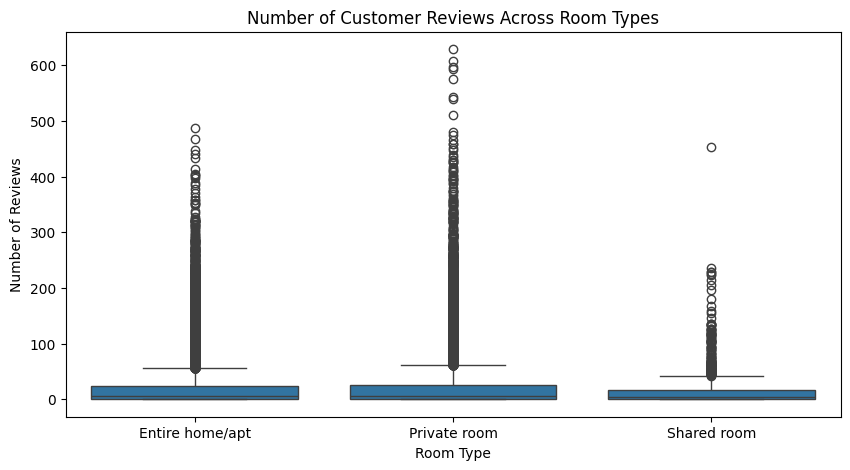

In [77]:
plt.figure(figsize=(10,5))

sns.boxplot(data=df, x='room_type', y='number_of_reviews')

plt.title('Number of Customer Reviews Across Room Types')
plt.xlabel('Room Type')
plt.ylabel('Number of Reviews')

plt.show()

In [78]:
df.groupby('room_type', observed=False)['number_of_reviews'].median()

,number_of_reviews
room_type,
Entire home/apt,5.0
Private room,5.0
Shared room,4.0


**Interpretation**

The boxplot shows that Private rooms have the highest median number of customer reviews, followed closely by Entire home/apartment listings. Shared rooms generally receive fewer reviews and exhibit a narrower distribution. Although all room types contain listings with exceptionally high review counts, the most highly reviewed properties are predominantly found among Private rooms. This suggests greater variation in guest engagement for private room listings.

**Business Insight**

The results suggest that Entire home/apartment and Private room listings experience similar levels of typical customer engagement, as reflected by their equal median number of reviews. However, Private rooms show greater variability and include some of the most highly reviewed listings, indicating that certain private room properties are particularly popular among guests. Shared rooms receive fewer reviews overall, suggesting comparatively lower guest demand.

## 2.7 Number of Reviews vs Neighbourhood Group
**Business Question**

How does the number of customer reviews vary across different neighbourhood groups in New York City?

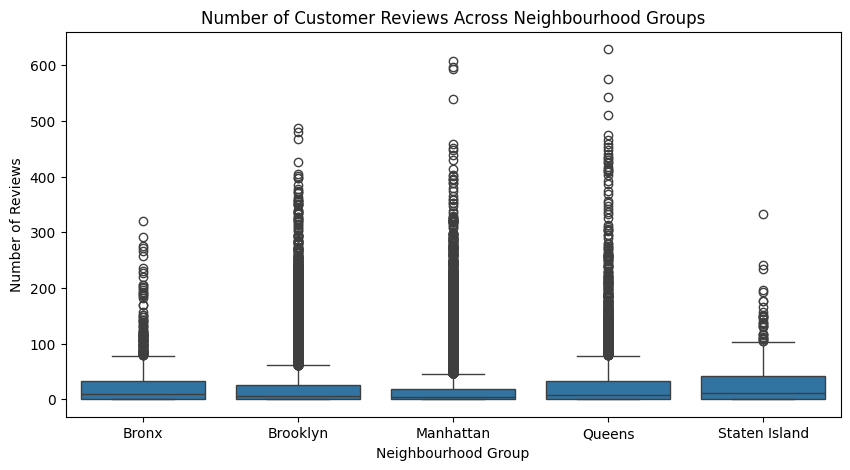

In [79]:
plt.figure(figsize=(10,5))

sns.boxplot(data=df, x='neighbourhood_group', y='number_of_reviews')

plt.title('Number of Customer Reviews Across Neighbourhood Groups')
plt.xlabel('Neighbourhood Group')
plt.ylabel('Number of Reviews')

plt.show()

In [80]:
df.groupby('neighbourhood_group', observed=False)['number_of_reviews'].median()

,number_of_reviews
neighbourhood_group,
Bronx,9.0
Brooklyn,6.0
Manhattan,4.0
Queens,7.0
Staten Island,12.0


**Interpretation**

The boxplot shows noticeable differences in the distribution of customer reviews across neighbourhood groups. Based on the median values, Staten Island has the highest median number of reviews, followed by the Bronx, Queens, Brooklyn, and Manhattan. Although Manhattan contains several listings with exceptionally high review counts, its median number of reviews is the lowest among all neighbourhood groups. This indicates that while some Manhattan listings are extremely popular, a large proportion receive relatively few reviews.

**Business Insight**

The results suggest that the typical level of customer engagement differs across neighbourhood groups. Despite having the largest number of Airbnb listings, Manhattan does not have the highest typical number of reviews. In contrast, listings in Staten Island and the Bronx tend to receive more reviews on a typical basis, which may indicate longer listing lifespans, higher occupancy, or more consistent guest activity. Further analysis would be needed to determine the underlying reasons for these differences.

## 2.8 Availability vs Room Type
**Business Question**

How does the annual availability of Airbnb listings vary across different room types?

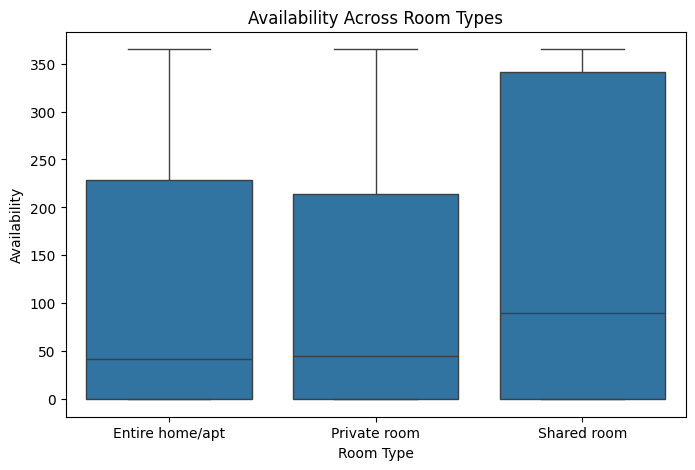

In [81]:
plt.figure(figsize=(8,5))

sns.boxplot(data=df, x='room_type', y='availability_365')

plt.title('Availability Across Room Types')
plt.xlabel('Room Type')
plt.ylabel('Availability')

plt.show()

In [82]:
df.groupby('room_type', observed=False)['availability_365'].median()

,availability_365
room_type,
Entire home/apt,42.0
Private room,45.0
Shared room,90.0


**Interpretation**

The boxplot shows noticeable differences in annual availability across room types. Shared rooms have the highest median availability (90 days), indicating that they remain available for booking longer than other room types. Private rooms and Entire home/apartment listings have similar median availability, with 45 days and 42 days, respectively. The wider spread observed for shared rooms suggests greater variation in their availability throughout the year.

**Business Insight**

The results suggest that Shared rooms are generally available for booking for a longer period of the year compared to private rooms and entire homes. This may indicate lower booking demand or lower occupancy rates for shared accommodations. In contrast, the lower median availability of Entire home/apartment and Private room listings may reflect higher occupancy or more frequent bookings, making them less available throughout the year.

## 2.9 Availability vs Neighbourhood Group
**Business Question**

How does the annual availability of Airbnb listings vary across different neighbourhood groups in New York City?

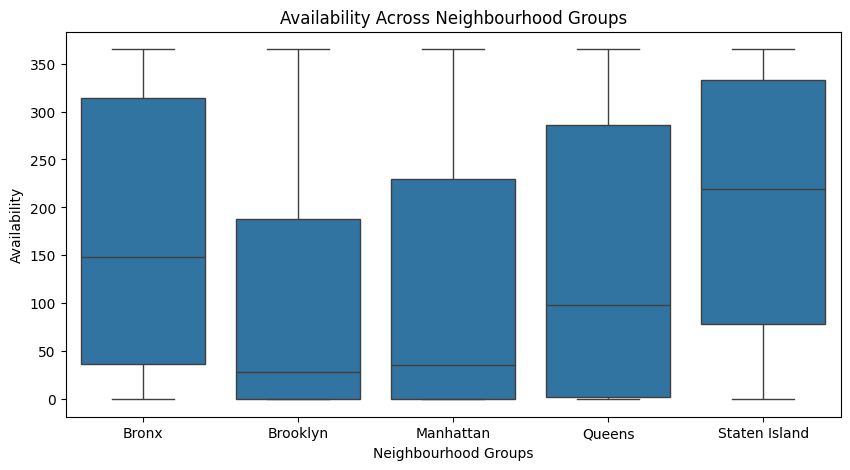

In [83]:
plt.figure(figsize=(10,5))

sns.boxplot(data=df, x='neighbourhood_group', y='availability_365')

plt.title('Availability Across Neighbourhood Groups')
plt.xlabel('Neighbourhood Groups')
plt.ylabel('Availability')

plt.show()

In [84]:
df.groupby('neighbourhood_group', observed=False)['availability_365'].median()

,availability_365
neighbourhood_group,
Bronx,148.0
Brooklyn,28.0
Manhattan,36.0
Queens,98.0
Staten Island,219.0


**Interpretation**

The boxplot reveals substantial differences in annual availability across neighbourhood groups. Staten Island has the highest median annual availability (219 days), followed by the Bronx (148 days) and Queens (98 days). In contrast, Manhattan (36 days) and Brooklyn (28 days) have the lowest median availability. This indicates that listings in Staten Island and the Bronx tend to remain available for booking for longer periods, whereas listings in Manhattan and Brooklyn are available for fewer days throughout the year.

**Business Insight**

The findings suggest that Airbnb listings in Manhattan and Brooklyn may experience higher occupancy rates or more frequent bookings, resulting in lower annual availability. Conversely, the higher availability observed in Staten Island, Bronx, and Queens may indicate lower occupancy or hosts keeping their properties available for longer periods. This highlights how listing availability varies considerably across neighbourhood groups and may reflect differences in tourism demand, host behavior, or local market dynamics.

## 2.10 Minimum Nights vs Room Type
**Business Question**

How do minimum night requirements differ across different room types?

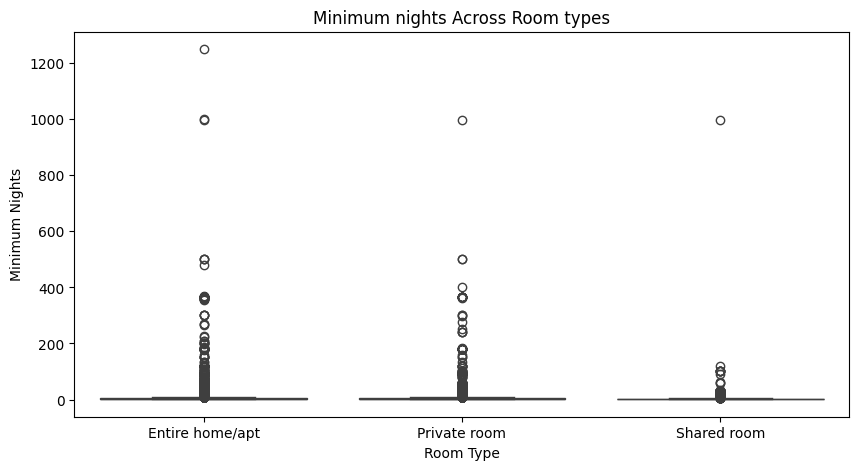

In [85]:
plt.figure(figsize=(10,5))

sns.boxplot(data=df, x='room_type', y='minimum_nights')

plt.title('Minimum nights Across Room types')
plt.xlabel('Room Type')
plt.ylabel('Minimum Nights')

plt.show()

In [86]:
df.groupby('room_type', observed=False)['minimum_nights'].median()

,minimum_nights
room_type,
Entire home/apt,3.0
Private room,2.0
Shared room,1.0


**Interpretation**

The boxplot and median values reveal clear differences in minimum night requirements across room types. Entire home/apartment listings have the highest median minimum stay (3 nights), followed by Private rooms (2 nights) and Shared rooms (1 night). Although all room types contain listings with exceptionally high minimum stay requirements, these represent a small number of outliers. Overall, shared rooms tend to offer the most flexible booking policies, while entire homes generally require longer minimum stays.

**Business Insight**

The results suggest that hosts of entire homes typically require longer minimum stays, possibly to reduce guest turnover, cleaning costs, or operational effort. In contrast, shared room hosts tend to allow shorter stays, making them more suitable for travelers seeking flexible or short-term accommodation. This indicates that booking policies vary by room type and may reflect different hosting strategies and target customer segments.

## 2.11 Minimum Nights vs Neighbourhood Group

**Business Question**

How do minimum night requirements vary across different neighbourhood groups in New York City?

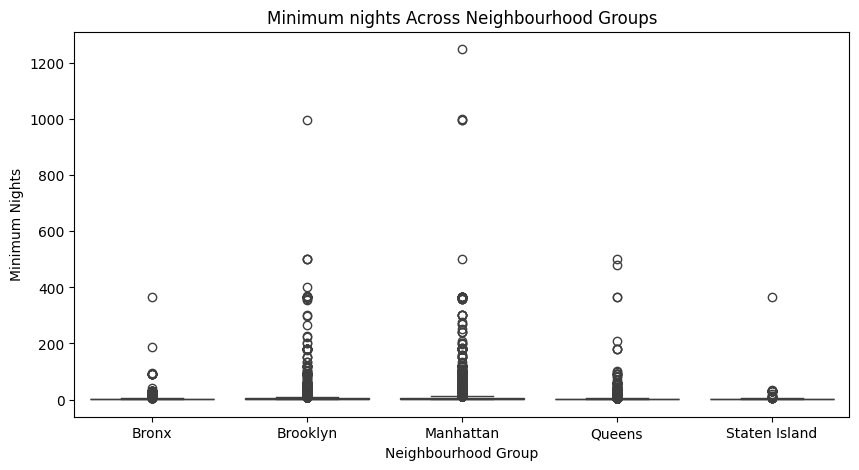

In [87]:
plt.figure(figsize=(10,5))

sns.boxplot(data=df, x='neighbourhood_group', y='minimum_nights')

plt.title('Minimum nights Across Neighbourhood Groups')
plt.xlabel('Neighbourhood Group')
plt.ylabel('Minimum Nights')

plt.show()

In [88]:
df.groupby('neighbourhood_group', observed=False)['minimum_nights'].median()

,minimum_nights
neighbourhood_group,
Bronx,2.0
Brooklyn,3.0
Manhattan,3.0
Queens,2.0
Staten Island,2.0


**Interpretation**

The boxplot and median values indicate that Manhattan and Brooklyn have the highest median minimum night requirement (3 nights), while the Bronx, Queens, and Staten Island each have a median minimum stay of 2 nights. Although all neighbourhood groups contain listings with exceptionally high minimum stay requirements, these represent a small number of outliers. Overall, the typical difference in minimum night requirements across neighbourhood groups is relatively modest.

**Business Insight**

The results suggest that hosts in Manhattan and Brooklyn generally require slightly longer minimum stays than hosts in the other boroughs. This may reflect differences in hosting strategies, operational costs, or market demand in these highly active Airbnb markets. However, since the median difference is only one night, location appears to have a relatively small influence on typical minimum stay requirements compared with other factors.

# 3. Multivariate Analysis

## 3.1 Average Price by Room Type and Neighbourhood Group
**Business Question**

How does the average Airbnb listing price vary across different combinations of room type and neighbourhood group?

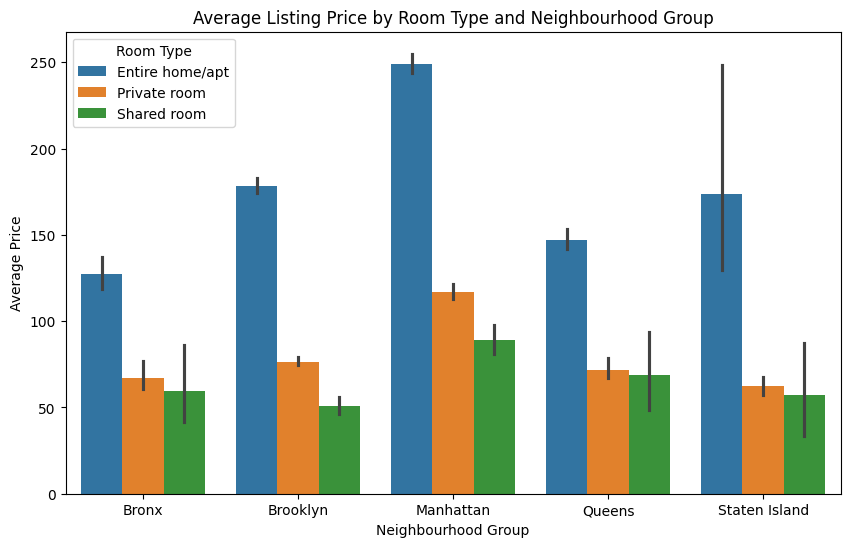

In [89]:
plt.figure(figsize=(10,6))

sns.barplot(data=df, x='neighbourhood_group', y='price', hue='room_type', estimator='mean')

plt.title('Average Listing Price by Room Type and Neighbourhood Group')
plt.xlabel('Neighbourhood Group')
plt.ylabel('Average Price')
plt.legend(title='Room Type')

plt.show()

**Interpretation**

The grouped bar chart shows that entire homes/apartments consistently have the highest average listing prices across all neighbourhood groups, while shared rooms are the most affordable option. Among all neighbourhood groups, Manhattan records the highest average prices for every room type, with entire homes/apartments averaging around $250, indicating its premium position in the Airbnb market. Brooklyn follows Manhattan with relatively high average prices, whereas Queens, the Bronx, and Staten Island generally offer more affordable listings. The chart also reveals that private rooms are priced between entire homes and shared rooms across all neighbourhood groups. Additionally, the larger error bars for Staten Island's entire homes/apartments suggest greater variability in listing prices, indicating that accommodation prices in this neighbourhood are less consistent compared to others.

**Business Insights**

The analysis indicates that both room type and neighbourhood group play a significant role in determining Airbnb listing prices. Hosts in Manhattan, particularly those offering entire homes/apartments, have the opportunity to charge premium prices due to the area's high demand and popularity among visitors. In contrast, guests looking for more affordable accommodations can consider private or shared rooms in neighbourhoods such as the Bronx, Queens, or Brooklyn, where average prices are considerably lower. These findings suggest that pricing strategies should account for both the type of accommodation and its location to remain competitive while maximizing potential revenue.

## 3.2 Average Availability by Room Type and Neighbourhood Group
**Business Question**

How does the average annual availability of Airbnb listings vary across different combinations of room type and neighbourhood group?

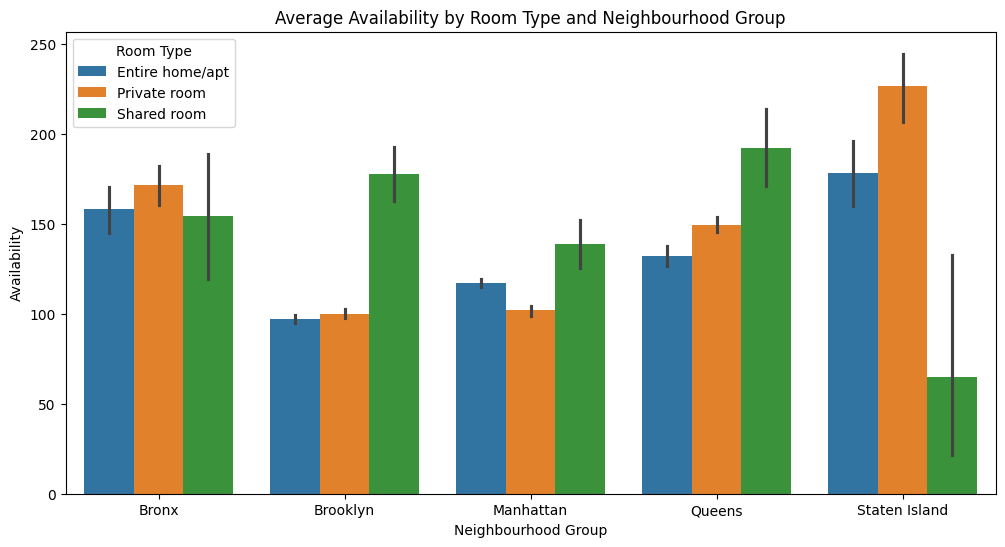

In [90]:
plt.figure(figsize=(12,6))

sns.barplot(data=df, x='neighbourhood_group', y='availability_365', hue='room_type', estimator='mean')

plt.title('Average Availability by Room Type and Neighbourhood Group')
plt.xlabel('Neighbourhood Group')
plt.ylabel('Availability')
plt.legend(title='Room Type')

plt.show()

**Interpretation**

The grouped bar chart shows that the average availability of Airbnb listings varies across both room types and neighbourhood groups. In the Bronx, private rooms have the highest average availability, while in Brooklyn, Manhattan, and Queens, shared rooms remain available for the greatest number of days throughout the year. Staten Island stands out, with private rooms showing the highest average availability among all room type and neighbourhood combinations, whereas shared rooms in Staten Island have the lowest average availability and exhibit high variability, as indicated by the large error bars. Overall, the analysis suggests that the availability of listings is influenced by both the type of accommodation and its location, with noticeable differences across neighbourhood groups.

**Business Insights**

The findings indicate that listing availability is not solely determined by room type but also by the neighbourhood in which the property is located. Higher availability may suggest that a listing is available for booking for more days during the year, which could indicate lower occupancy rates or hosts making their properties available more frequently. Conversely, listings with lower availability may reflect higher booking demand or limited host availability. These insights can help hosts evaluate their listing strategies and enable guests to identify neighbourhoods and room types that are more likely to have accommodations available throughout the year.

## 3.3 Average Minimum Nights by Room Type and Neighbourhood Group
**Business Question**

How do the average minimum night stay requirements vary across different combinations of room type and neighbourhood group?

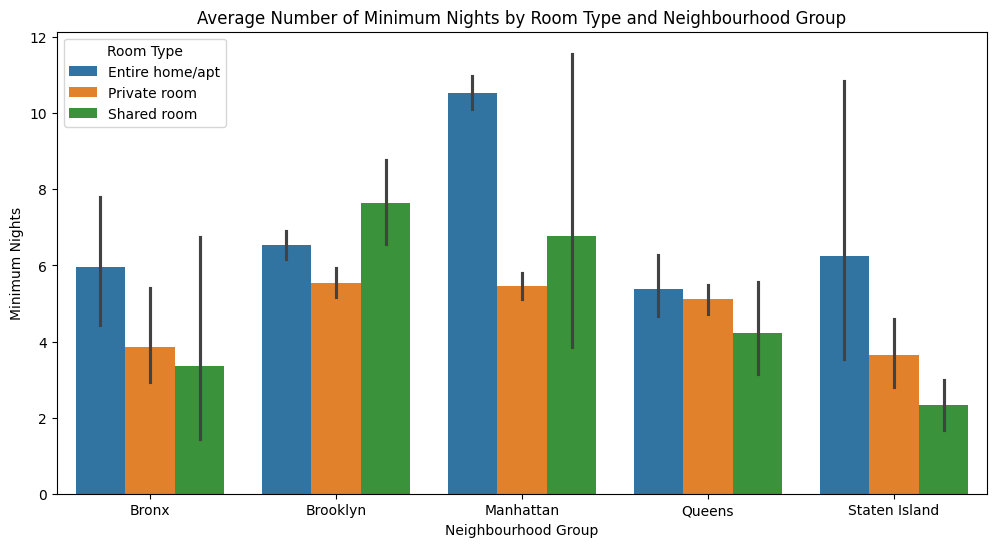

In [91]:
plt.figure(figsize=(12,6))

sns.barplot(data=df, x='neighbourhood_group', y='minimum_nights', hue='room_type', estimator='mean')

plt.title('Average Number of Minimum Nights by Room Type and Neighbourhood Group')
plt.xlabel('Neighbourhood Group')
plt.ylabel('Minimum Nights')
plt.legend(title='Room Type')

plt.show()

**Interpretation**

The grouped bar chart illustrates that the average minimum night stay requirement varies across both room types and neighbourhood groups. Entire homes/apartments generally have higher minimum night requirements than private and shared rooms, with Manhattan recording the highest average minimum stay of approximately 10 nights for entire homes/apartments. Private rooms exhibit relatively consistent minimum night requirements across all neighbourhood groups, typically ranging between 4 and 6 nights. Shared rooms display greater variation, with Brooklyn and Manhattan having higher average minimum stay requirements, while Staten Island has the lowest average minimum nights for shared rooms. Additionally, the larger error bars observed for shared rooms in Manhattan and entire homes in Staten Island indicate greater variability in minimum stay policies within these categories.

**Business Insights**

The analysis suggests that hosts of entire homes/apartments, particularly in Manhattan, tend to require longer minimum stays, possibly to maximize revenue and reduce the operational costs associated with frequent guest turnover. In contrast, private and shared rooms generally offer shorter minimum stay requirements, making them more attractive to travelers seeking flexible or short-term accommodations. These findings can help guests choose listings that match their travel duration, while enabling hosts to evaluate whether their minimum stay policies are competitive within their neighbourhood and room type.

## 3.4 Listing Distribution by Room Type Across Neighbourhood Groups
**Business Question**

How are Airbnb listings distributed across different room types within each neighbourhood group?

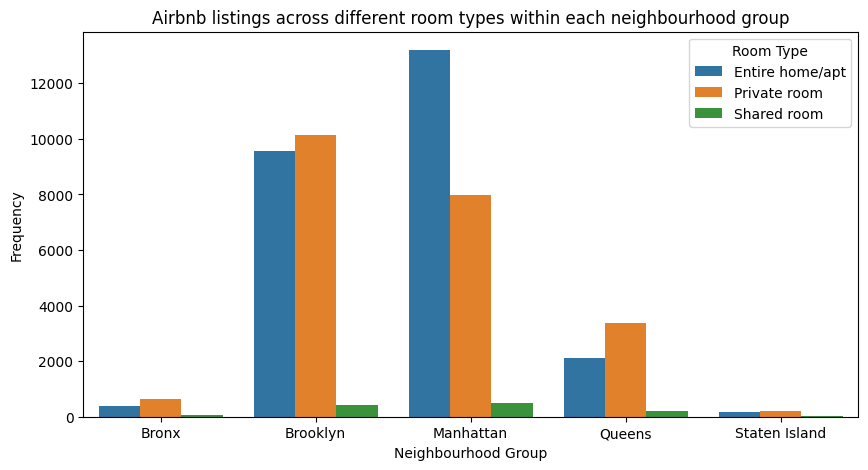

In [92]:
plt.figure(figsize=(10,5))

sns.countplot(data=df, x='neighbourhood_group', hue='room_type')

plt.title('Airbnb listings across different room types within each neighbourhood group')
plt.xlabel('Neighbourhood Group')
plt.ylabel('Frequency')
plt.legend(title='Room Type')

plt.show()

**Interpretation**

The countplot illustrates that the distribution of Airbnb listings varies considerably across both room types and neighbourhood groups. Manhattan and Brooklyn account for the highest number of listings, indicating that these neighbourhoods dominate the Airbnb market in New York City. In Manhattan, entire homes/apartments are the most common listing type, while Brooklyn has a slightly higher number of private room listings than entire homes. Queens also has a noticeable number of private rooms, although its overall listing count is substantially lower than Manhattan and Brooklyn. In contrast, the Bronx and Staten Island have relatively few Airbnb listings across all room types. Shared rooms represent the smallest proportion of listings in every neighbourhood group, suggesting that they are the least common accommodation option throughout the city.

**Business Insights**

The analysis indicates that Airbnb's market is highly concentrated in Manhattan and Brooklyn, where the largest supply of listings provides guests with the greatest variety of accommodation choices. The dominance of entire homes in Manhattan reflects strong demand for premium accommodations, whereas the higher proportion of private rooms in Brooklyn suggests a market catering to more budget-conscious travelers. Since shared rooms are limited across all neighbourhood groups, guests seeking this accommodation type have fewer options, while hosts may identify potential opportunities in markets where supply is relatively low if demand exists.

## 3.5 Correlation Analysis
**Business Question**

What relationships exist among the numerical variables in the Airbnb dataset, and which variables are positively or negatively correlated with each other?

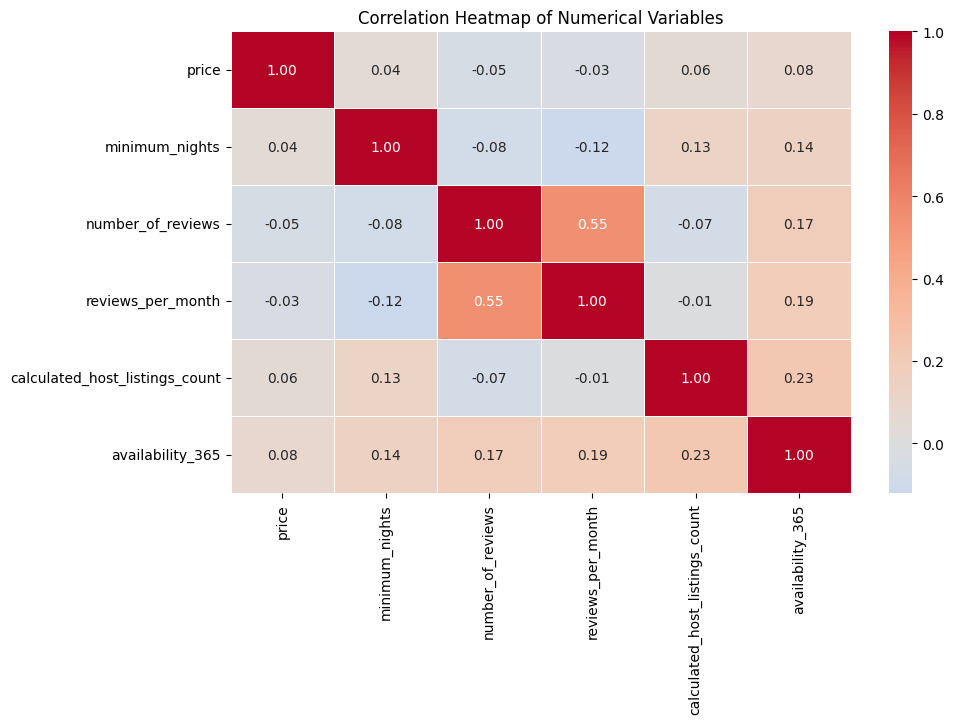

In [93]:
plt.figure(figsize=(10,6))

corr = df[['price',
           'minimum_nights',
           'number_of_reviews',
           'reviews_per_month',
           'calculated_host_listings_count',
           'availability_365']].corr()

sns.heatmap(
    corr,
    annot=True,
    cmap='coolwarm',
    fmt='.2f',
    linewidths=0.5,
    center=0
)

plt.title('Correlation Heatmap of Numerical Variables')
plt.show()

**Interpretation**

The correlation heatmap indicates that most numerical variables exhibit weak correlations with one another, suggesting that they are largely independent. The strongest positive correlation is observed between number_of_reviews and reviews_per_month (0.55), indicating that listings with a higher total number of reviews generally receive reviews more frequently each month. Availability (availability_365) shows weak positive correlations with calculated_host_listings_count (0.23), reviews_per_month (0.19), and number_of_reviews (0.17), implying a slight tendency for hosts with more listings or more active properties to have greater annual availability. On the other hand, price has negligible correlations with all other numerical variables, indicating that pricing is not strongly influenced by factors such as minimum nights, number of reviews, review frequency, host listing count, or annual availability. Overall, the heatmap suggests that there are no strong linear relationships among most of the numerical variables in the dataset.

**Business Insights**

The correlation analysis suggests that no single numerical variable strongly determines Airbnb listing prices, indicating that pricing is likely influenced by other factors such as location, room type, property characteristics, and amenities, rather than the numerical variables examined in this analysis. The moderate positive relationship between number of reviews and reviews per month reflects that popular listings tend to receive reviews more consistently over time. Additionally, the weak correlations among the remaining variables indicate that hosts and platform managers should consider multiple factors collectively rather than relying on a single metric when evaluating listing performance or developing pricing strategies.

## 3.6 Top Hosts by Number of Listings
**Business Question**

Which Airbnb hosts own the largest number of listings in New York City?

Variables

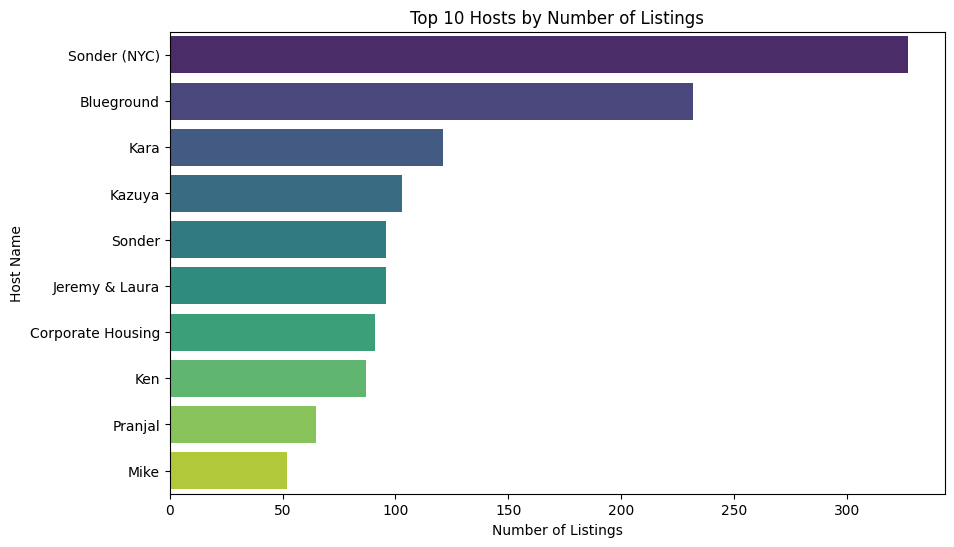

In [94]:
top_hosts = (
    df[['host_name', 'calculated_host_listings_count']]
    .drop_duplicates()
    .sort_values(by='calculated_host_listings_count', ascending=False)
    .head(10)
)

plt.figure(figsize=(10,6))

sns.barplot(
    data=top_hosts,
    x='calculated_host_listings_count',
    y='host_name',
    hue='host_name',
    palette='viridis',
    legend=False
)

plt.title('Top 10 Hosts by Number of Listings')
plt.xlabel('Number of Listings')
plt.ylabel('Host Name')

plt.show()

**Interpretation**

The horizontal bar chart highlights the top 10 Airbnb hosts based on the number of listings they manage in New York City. Sonder (NYC) stands out as the largest host, managing over 320 listings, significantly exceeding all other hosts in the dataset. Blueground ranks second with approximately 230 listings, while the remaining hosts manage considerably fewer properties, with listing counts generally ranging between 50 and 130. The substantial gap between the top two hosts and the rest suggests that a small number of hosts operate on a much larger scale than typical Airbnb hosts. This indicates the presence of professional property management companies or commercial hosts alongside individual property owners on the platform.

**Business Insights**

The analysis reveals that Airbnb's supply is partially concentrated among a few large-scale hosts, with companies such as Sonder (NYC) and Blueground managing a significant number of listings. These hosts are likely to benefit from economies of scale, standardized operations, and greater market visibility. In contrast, individual hosts with fewer listings may need to compete through competitive pricing, unique guest experiences, or specialized property offerings. Understanding the dominance of large hosts can also help Airbnb monitor market concentration and ensure a balanced marketplace that supports both commercial operators and independent hosts.

## 3.7 Most Expensive Neighbourhoods
**Business Question**

Which neighbourhoods have the highest average Airbnb listing prices in New York City?

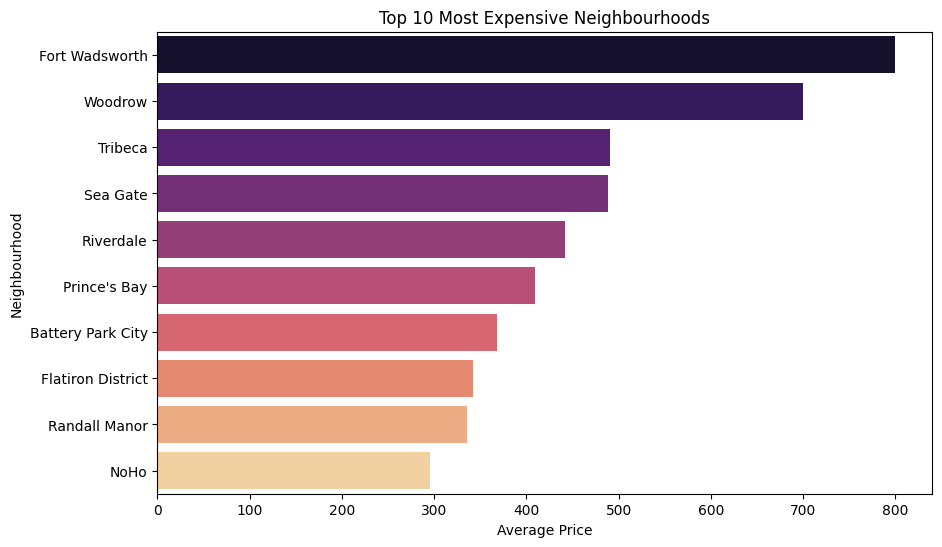

In [95]:
top_neighbourhoods = (
    df.groupby('neighbourhood', observed=False)['price']
      .mean()
      .sort_values(ascending=False)
      .head(10)
      .reset_index()
)
top_neighbourhoods['neighbourhood'] = top_neighbourhoods['neighbourhood'].astype(str)

plt.figure(figsize=(10,6))

sns.barplot(
    data= top_neighbourhoods,
    x='price',
    y='neighbourhood',
    hue='neighbourhood',
    palette='magma',
    legend=False
)

plt.title('Top 10 Most Expensive Neighbourhoods')
plt.xlabel('Average Price')
plt.ylabel('Neighbourhood')

plt.show()

**Interpretation**

The horizontal bar chart shows the top 10 neighbourhoods with the highest average Airbnb listing prices in New York City. Fort Wadsworth ranks as the most expensive neighbourhood, with an average listing price of approximately 800 USD, followed by Woodrow at around 700 USD. Tribeca and Sea Gate also have notably high average prices, both exceeding $480. The remaining neighbourhoods, including Riverdale, Prince's Bay, Battery Park City, Flatiron District, Randall Manor, and NoHo, have average listing prices ranging from approximately 295 to 443 USD. The substantial price differences among these neighbourhoods indicate that location has a significant influence on Airbnb pricing.

**Business Insights**

The analysis highlights that certain neighbourhoods command significantly higher average listing prices than others, reflecting differences in demand, exclusivity, accessibility, and local amenities. Hosts operating in premium neighbourhoods such as Fort Wadsworth, Woodrow, and Tribeca have greater potential to generate higher revenue through premium pricing strategies. Meanwhile, guests planning trips with budget constraints may benefit from considering neighbourhoods outside these high-priced areas. These findings emphasize the importance of neighbourhood selection as a key factor influencing Airbnb pricing decisions.

## 3.8 Most Reviewed Neighbourhoods
**Business Question**

Which neighbourhoods receive the highest average number of customer reviews on Airbnb?

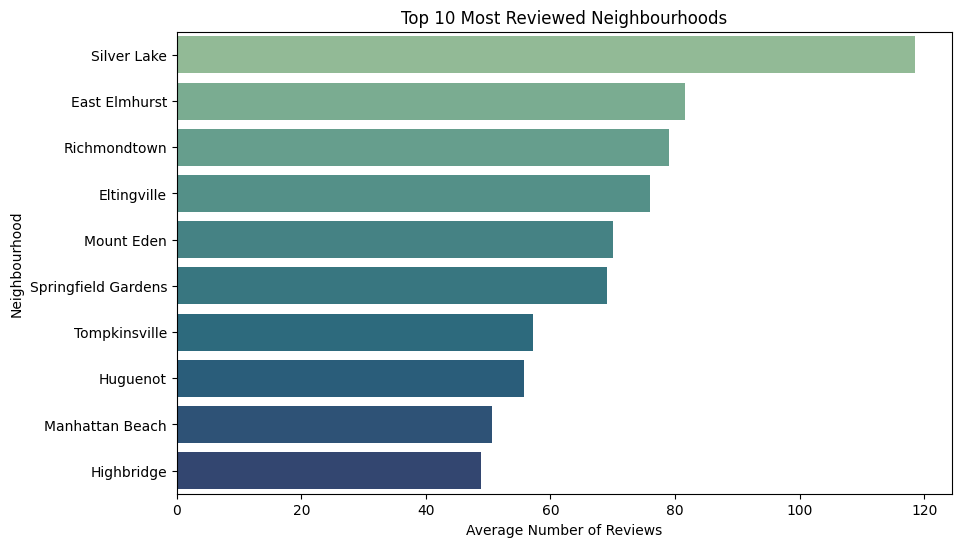

In [96]:
top_reviewed = (
    df.groupby('neighbourhood', observed=False)['number_of_reviews']
      .mean()
      .sort_values(ascending=False)
      .head(10)
      .reset_index()
)

top_reviewed['neighbourhood'] = top_reviewed['neighbourhood'].astype(str)

plt.figure(figsize=(10,6))

sns.barplot(
    data=top_reviewed,
    x='number_of_reviews',
    y='neighbourhood',
    hue='neighbourhood',
    palette='crest',
    legend=False
)

plt.title('Top 10 Most Reviewed Neighbourhoods')
plt.xlabel('Average Number of Reviews')
plt.ylabel('Neighbourhood')

plt.show()

**Interpretation**

The horizontal bar chart presents the top 10 neighbourhoods with the highest average number of Airbnb reviews in New York City. Silver Lake ranks first, with an average of approximately 117 reviews per listing, indicating a high level of guest engagement. East Elmhurst, Richmondtown, and Eltingville also record relatively high average review counts, each exceeding 75 reviews. The remaining neighbourhoods, including Mount Eden, Springfield Gardens, Tompkinsville, Huguenot, Manhattan Beach, and Highbridge, have average review counts ranging from approximately 49 to 70. The variation in average review counts suggests that some neighbourhoods consistently receive more guest feedback than others, reflecting differences in booking activity and guest engagement.

**Business Insights**

The analysis suggests that certain neighbourhoods experience higher guest engagement, as reflected by their larger average number of reviews. A higher review count may indicate that listings in these neighbourhoods receive more bookings or have been active on the platform for a longer period. For hosts, neighbourhoods with consistently higher review activity may represent areas with stronger market demand and greater visibility. However, review count alone should not be interpreted as a direct measure of profitability, as pricing, occupancy rates, and listing quality also influence overall performance.

## 3.9 Top Hosts by Average Price
**Business Question**

Which Airbnb hosts charge the highest average prices for their listings in New York City?

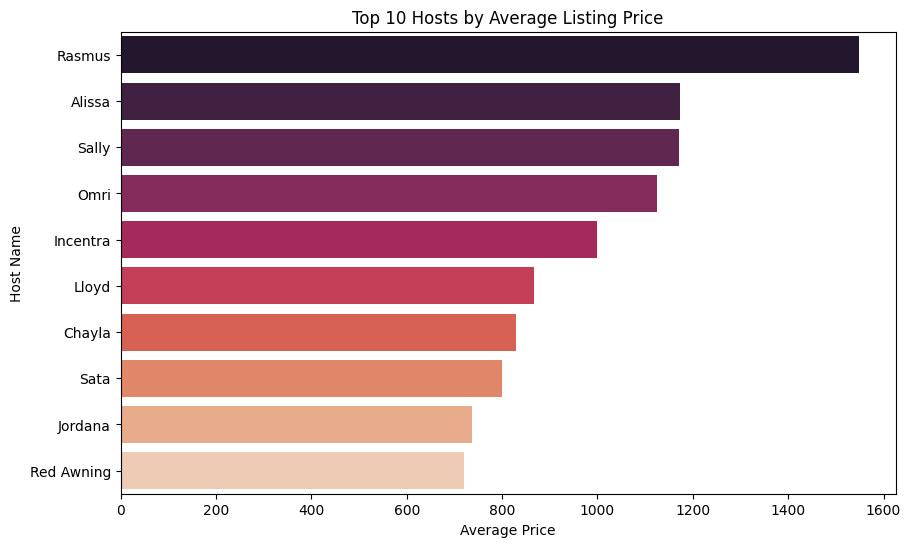

In [97]:
host_avg_price = (
    df.groupby('host_name')
      .agg(
          average_price=('price', 'mean'),
          listing_count=('host_name', 'count')
      )
      .query('listing_count >= 5')
      .sort_values(by='average_price', ascending=False)
      .head(10)
      .reset_index()
)

plt.figure(figsize=(10,6))

sns.barplot(
    data=host_avg_price,
    x='average_price',
    y='host_name',
    hue='host_name',
    palette='rocket',
    legend=False
)

plt.title('Top 10 Hosts by Average Listing Price')
plt.xlabel('Average Price')
plt.ylabel('Host Name')

plt.show()

**Interpretation**

The horizontal bar chart displays the top 10 Airbnb hosts with the highest average listing prices, considering only hosts with at least five listings. Rasmus ranks first, with an average listing price of approximately 1,550 USD, significantly higher than the other hosts in the ranking. Alissa, Sally, and Omri follow, each maintaining average listing prices exceeding 1,100 USD. The remaining hosts, including Incentra, Lloyd, Chayla, Sata, Jordana, and Red Awning, have average listing prices ranging from approximately 700 USD to 1,000 USD. The noticeable differences in average prices suggest that some hosts consistently position their listings within the luxury segment of the Airbnb market.

**Business Insights**

The analysis indicates that a small group of hosts consistently charge premium prices across multiple listings, suggesting that they may specialize in luxury accommodations or operate properties located in high-demand neighbourhoods. Filtering the analysis to hosts with at least five listings improves the reliability of the ranking by reducing the influence of hosts with only one or two unusually expensive properties. These insights can help Airbnb understand pricing strategies adopted by professional hosts, while also providing benchmarks for other hosts aiming to position their listings within the premium market.

# Final Conclusion / Key Findings

The exploratory data analysis of the New York City Airbnb dataset provided valuable insights into the factors influencing listing prices, availability, minimum stay requirements, and overall market distribution. The analysis revealed that location and room type are the primary factors affecting Airbnb pricing, with Manhattan consistently recording the highest average listing prices, particularly for entire homes and apartments. Entire homes/apartments were found to be the most expensive accommodation type across all neighbourhood groups, while shared rooms remained the most affordable.

The study also showed that Airbnb listings are heavily concentrated in Manhattan and Brooklyn, indicating that these neighbourhood groups dominate the city's short-term rental market. In contrast, neighbourhood groups such as the Bronx and Staten Island contain relatively fewer listings, offering guests fewer accommodation choices.

Correlation analysis indicated that most numerical variables have weak linear relationships, suggesting that listing price is not strongly influenced by factors such as minimum nights, number of reviews, review frequency, host listing count, or annual availability. The strongest positive correlation was observed between number of reviews and reviews per month, reflecting that popular listings tend to receive reviews more consistently over time.

The host-level analyses revealed that a small number of professional hosts manage a substantial number of Airbnb listings, while some hosts consistently charge premium prices across multiple properties. This highlights the presence of both commercial operators and individual hosts within the Airbnb marketplace.

Overall, the analysis demonstrates that pricing, listing distribution, and guest engagement are influenced by a combination of location, room type, and host characteristics. These insights can support hosts in developing competitive pricing strategies, guests in making informed accommodation choices, and platform managers in understanding market dynamics and identifying business opportunities.